# Scatter Plot

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

In [ ]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


# Scatter Plot for Age vs. Job Satisfaction

In [8]:
# Job Missing Value
job_missing = df['JobSatPoints_6'].isnull().sum()
job_missing

np.int64(35987)

In [9]:
# Age missing Value
Age_missing = df['Age'].isnull().sum()
Age_missing

np.int64(0)

In [14]:
# Handle Age categorical to numerical value
import re
def convert_age(column: str) -> int:
    if isinstance(column, str):
        if 'older' in column or 'Under' in column:
            match = re.search(r'\d+', column)
            if match:
                return int(match.group())
        elif 'Prefer not' in column:
            return 0
        else:
            match = re.findall(r'\d+', column)
            if match:
                return sum(int(i) for i in match) // len(match)  

In [15]:
df['Age'] = df['Age'].apply(convert_age)

In [16]:
df['Age'].value_counts()

Age
29    23911
39    14942
21    14098
49     6249
59     2575
18     2568
65      772
0       322
Name: count, dtype: int64

In [17]:
df['JobSatPoints_6'].value_counts()

JobSatPoints_6
0.00     7912
20.00    4352
10.00    3328
30.00    2482
15.00    1466
         ... 
73.00       1
6.25        1
57.00       1
61.00       1
63.00       1
Name: count, Length: 93, dtype: int64

In [18]:
df['JobSatPoints_6'] = df['JobSatPoints_6'].fillna(df['JobSatPoints_6'].mean())

In [20]:
job_missing = df['JobSatPoints_6'].isnull().sum()
job_missing

np.int64(0)

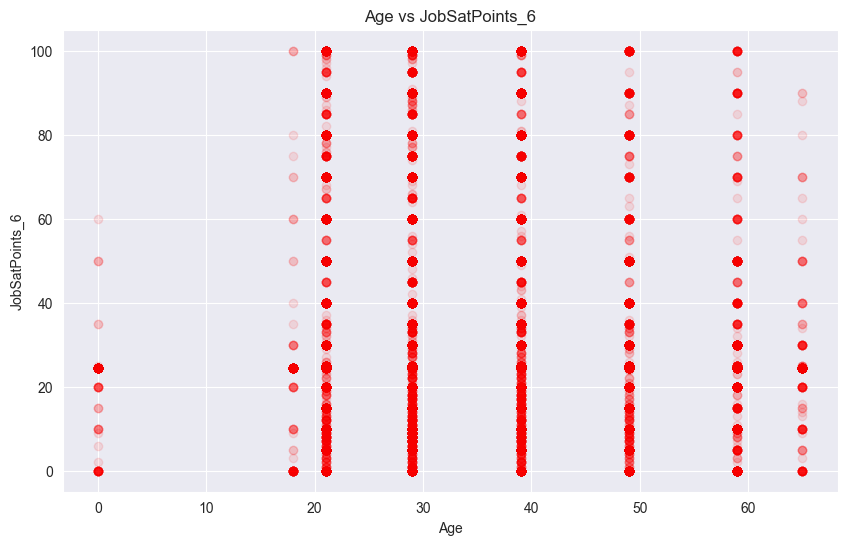

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['JobSatPoints_6'], alpha=0.1, color='red')
plt.xlabel('Age')
plt.ylabel('JobSatPoints_6')
plt.title('Age vs JobSatPoints_6')
plt.show()

In [30]:
df

,Age,JobSatPoints_6,AgeBin
0,56,66,"(55, 60]"
1,46,62,"(45, 50]"
2,32,1,"(30, 35]"
3,60,90,"(55, 60]"
4,25,44,"(20, 25]"
...,...,...,...
64995,58,46,"(55, 60]"
64996,24,47,"(20, 25]"
64997,64,97,"(60, 65]"
64998,52,42,"(50, 55]"
